#### Simple Linear Regression

![Regression Analysis Diagram](diagram_regression_analysis.png)

##  Linear Regression
`Regression Analysis` is a statistical method used to determine the `strength` and `character` of the relationship between one `dependent variable` (usually denoted by `Y`) and a series of other variables known as `independent variables`.
`Linear Regression` is a statistical technique where based on a set of `independent variable(s)` a dependent variable is `predicted`.

## Load Dataset

In [99]:
# !pip install numpy --upgrade # used to generate some data
# !pip install pandas --upgrade  # used to put the data into a dataframe
# !pip install matplotlib --upgrade # used for plot creating the charts
# !pip install seaborn --upgrade
# !pip install scikit-learn --upgrade # used to create the linear regression

In [100]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [102]:
df = pd.read_csv("boston_housing.csv")
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


## Dataset Analysis

In [103]:
df.keys()

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')

In [104]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
395,0.09065,20.0,6.96,1,0.464,5.920,61.5,3.9175,3,223.0,18.6,391.34,13.65,20.7
396,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223.0,18.6,388.65,13.00,21.1
397,0.16211,20.0,6.96,0,0.464,6.240,16.3,4.4290,3,223.0,18.6,396.90,6.59,25.2
398,0.11460,20.0,6.96,0,0.464,6.538,58.7,3.9175,3,223.0,18.6,394.96,7.73,24.4
399,0.22188,20.0,6.96,1,0.464,7.691,51.8,4.3665,3,223.0,18.6,390.77,6.58,35.2


In [105]:
df.sample(6)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
292,0.13642,0.0,10.59,0,0.4890,5.891,22.3,3.9454,4,277.0,18.6,396.90,10.87,22.6
281,0.03705,20.0,3.33,0,0.4429,6.968,37.2,5.2447,5,216.0,14.9,392.23,4.59,35.4
90,0.04684,0.0,3.41,0,0.4890,6.417,66.1,3.0923,2,270.0,17.8,392.18,8.81,22.6
357,0.46296,0.0,6.20,0,0.5040,7.412,76.9,3.6715,8,307.0,17.4,376.14,5.25,31.7
268,0.54050,20.0,3.97,0,0.5750,7.470,52.6,2.8720,5,264.0,13.0,390.30,3.16,43.5
355,0.44178,0.0,6.20,0,0.5040,6.552,21.4,3.3751,8,307.0,17.4,380.34,3.76,31.5


In [106]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.400492,15.421250,8.329100,0.137500,0.509467,6.522088,62.117250,4.279300,4.680000,304.582500,17.469000,380.963775,10.444750,26.886250
std,0.592608,25.251257,5.770709,0.344806,0.098462,0.779224,28.816459,1.940831,1.844208,63.710641,2.193734,37.973781,6.198467,9.324729
min,0.006320,0.000000,0.460000,0.000000,0.385000,4.903000,2.900000,1.321600,1.000000,188.000000,12.600000,70.800000,1.730000,11.800000
25%,0.078908,0.000000,4.050000,0.000000,0.438500,5.951000,35.500000,2.842500,4.000000,264.000000,16.400000,382.630000,5.515000,20.400000
50%,0.166705,0.000000,6.200000,0.000000,0.489000,6.373000,66.550000,3.877100,5.000000,300.000000,17.800000,391.600000,9.460000,24.000000
75%,0.475177,22.000000,10.590000,0.000000,0.538000,6.969750,88.650000,5.697275,5.000000,330.000000,18.700000,395.275000,13.620000,31.600000
max,4.097400,100.000000,25.650000,1.000000,0.871000,8.725000,100.000000,9.222900,8.000000,469.000000,21.200000,396.900000,34.410000,50.000000


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     400 non-null    float64
 1   ZN       400 non-null    float64
 2   INDUS    400 non-null    float64
 3   CHAS     400 non-null    int64  
 4   NOX      400 non-null    float64
 5   RM       400 non-null    float64
 6   AGE      400 non-null    float64
 7   DIS      400 non-null    float64
 8   RAD      400 non-null    int64  
 9   TAX      400 non-null    float64
 10  PTRATIO  400 non-null    float64
 11  B        400 non-null    float64
 12  LSTAT    400 non-null    float64
 13  MEDV     400 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 43.9 KB


In [108]:
df.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

## Exploratory Data Analysis

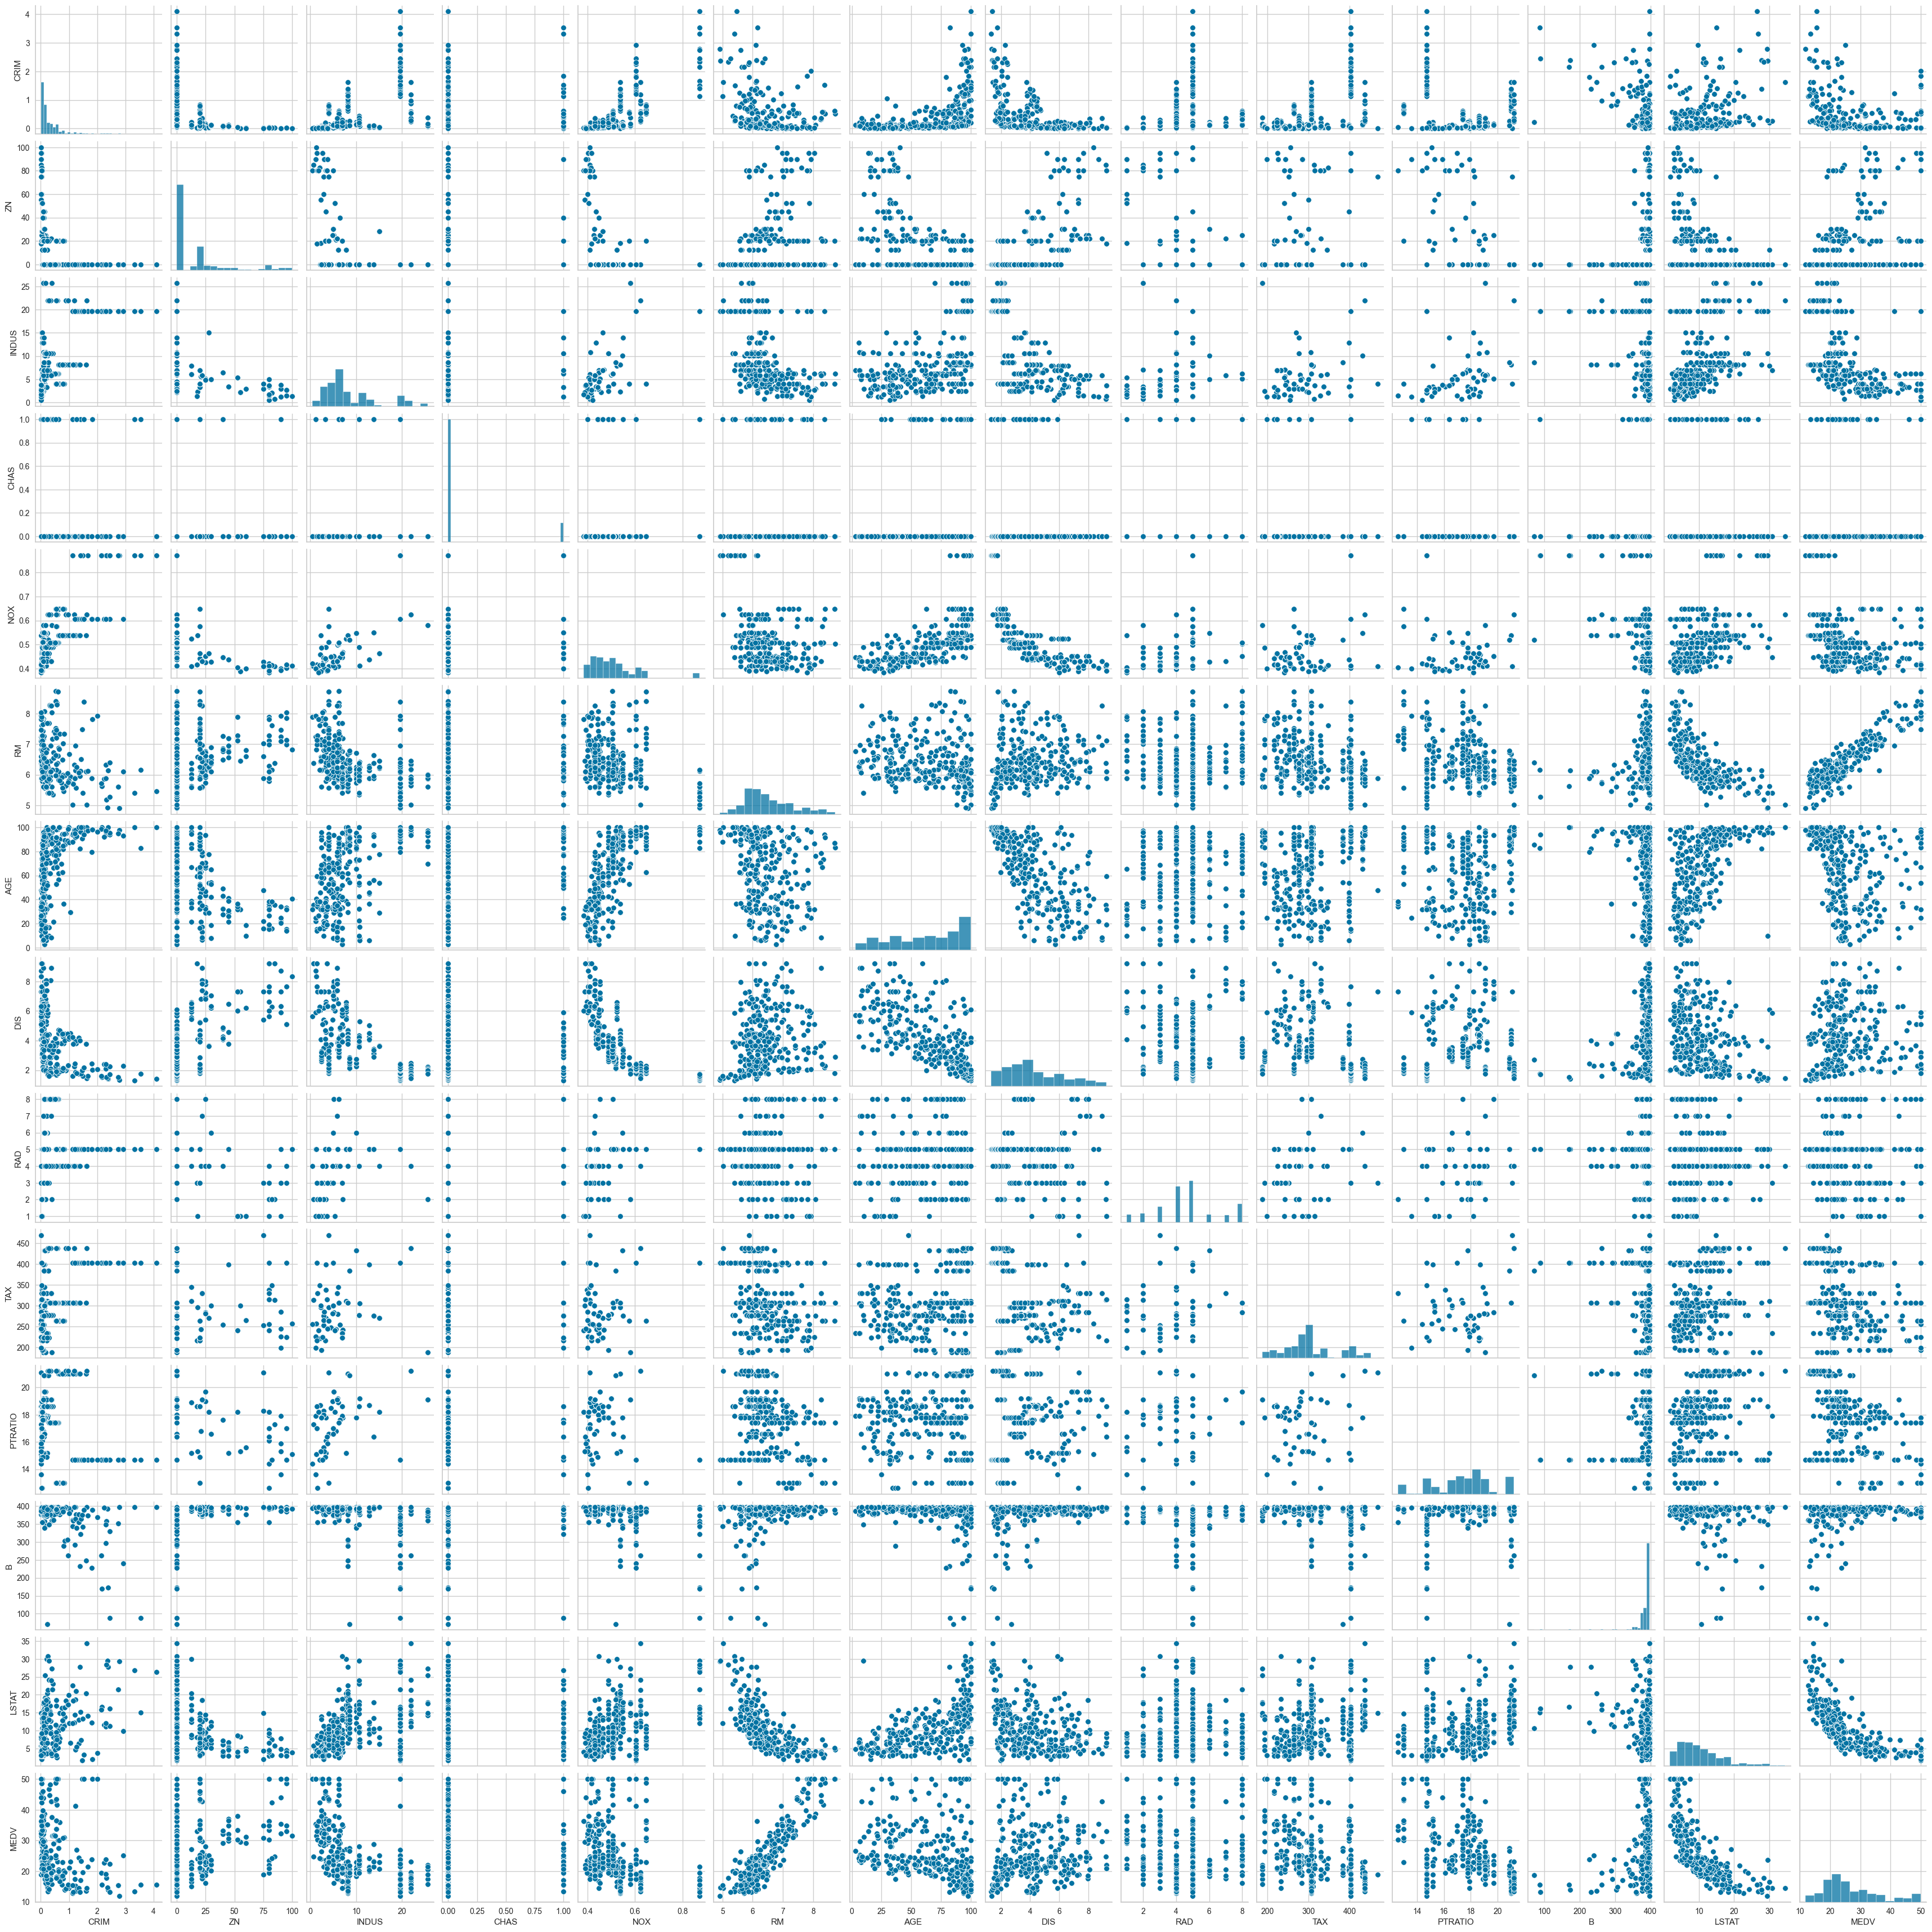

In [109]:
sns.pairplot(df)

In [110]:
corr_mat = df.corr()
corr_mat

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.302097,0.525272,0.048197,0.772805,-0.186266,0.473586,-0.465133,0.158431,0.432855,-0.219204,-0.519254,0.354670,-0.191137
ZN,-0.302097,1.000000,-0.467676,-0.123249,-0.453132,0.307672,-0.524338,0.612239,-0.351361,-0.148453,-0.322425,0.156026,-0.389757,0.340406
INDUS,0.525272,-0.467676,1.000000,0.125415,0.629218,-0.420050,0.472797,-0.536277,-0.013389,0.463348,0.183305,-0.311830,0.510995,-0.429028
CHAS,0.048197,-0.123249,0.125415,1.000000,0.076711,-0.068224,0.172998,-0.154592,0.089074,-0.093443,-0.069233,0.010478,0.165647,-0.019678
NOX,0.772805,-0.453132,0.629218,0.076711,1.000000,-0.211443,0.650401,-0.733094,0.155278,0.391870,-0.254047,-0.415412,0.435130,-0.217307
RM,-0.186266,0.307672,-0.420050,-0.068224,-0.211443,1.000000,-0.155091,0.059514,0.130267,-0.232704,-0.358429,0.154934,-0.712709,0.907053
AGE,0.473586,-0.524338,0.472797,0.172998,0.650401,-0.155091,1.000000,-0.660352,0.187090,0.263572,-0.006855,-0.200354,0.490235,-0.256257
DIS,-0.465133,0.612239,-0.536277,-0.154592,-0.733094,0.059514,-0.660352,1.000000,-0.126622,-0.205678,0.108386,0.216773,-0.305241,0.039186
RAD,0.158431,-0.351361,-0.013389,0.089074,0.155278,0.130267,0.187090,-0.126622,1.000000,0.287635,-0.025813,-0.060968,-0.055650,0.076928
TAX,0.432855,-0.148453,0.463348,-0.093443,0.391870,-0.232704,0.263572,-0.205678,0.287635,1.000000,0.110808,-0.273288,0.223584,-0.319797


<Axes: >

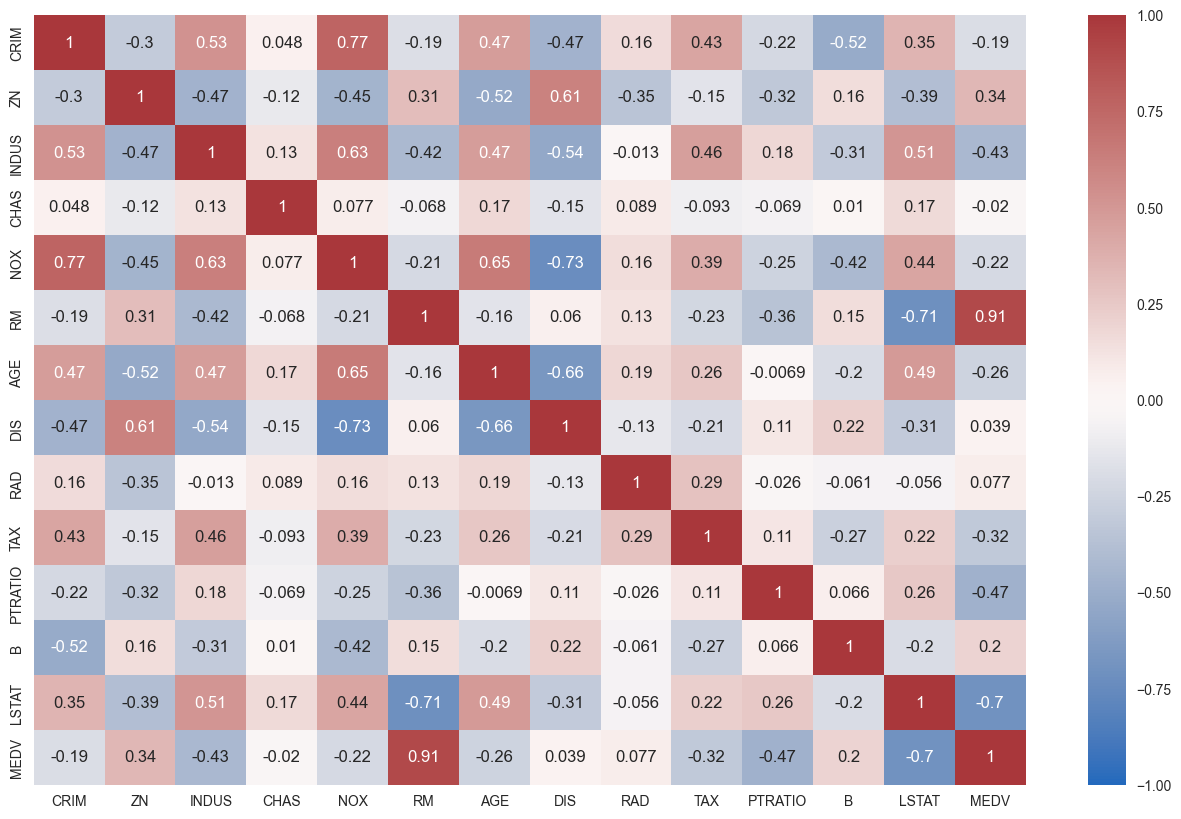

In [111]:
plt.subplots(figsize=(16, 10))
sns.heatmap(corr_mat, annot=True, annot_kws={'size': 12}, cmap='vlag',vmin=-1, vmax=1)

## Model Training

In [146]:
# Features (X)
X = df.drop(columns=["MEDV"])

# Target (y)
y = df["MEDV"]

In [147]:
X['Price'] = y

In [148]:
X.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'Price'],
      dtype='str')

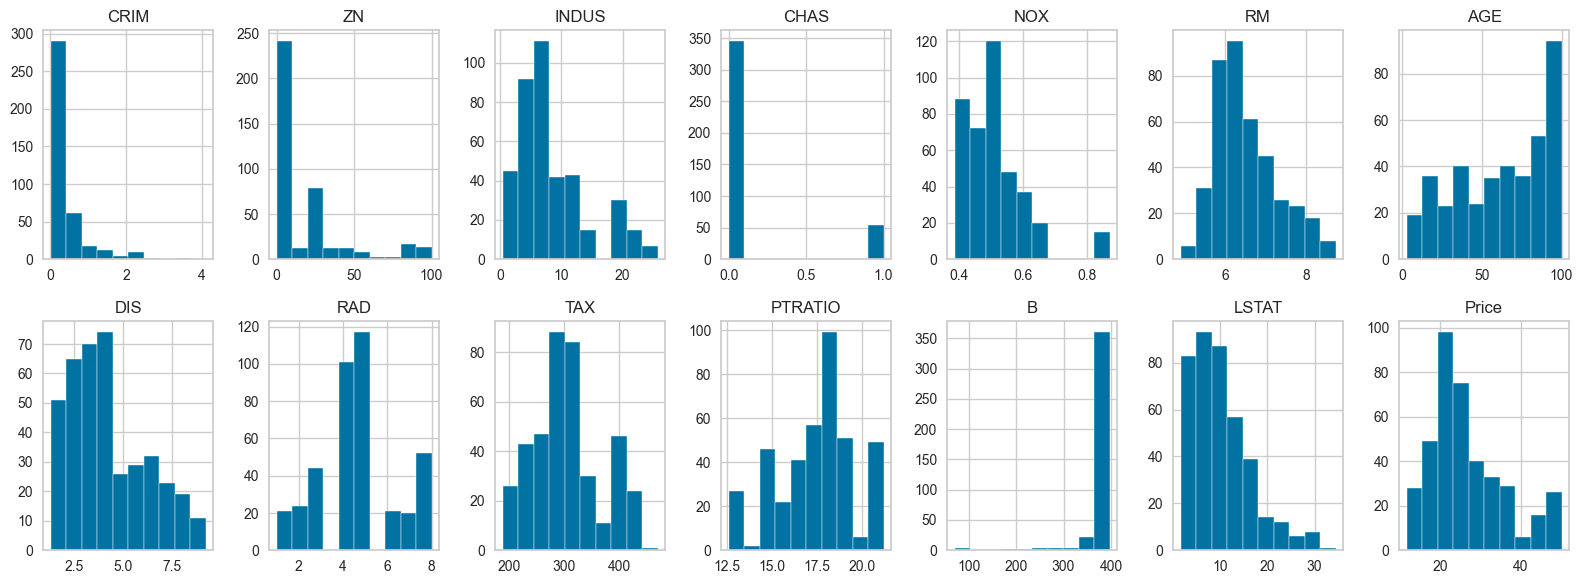

In [149]:
rows = 2
cols = 7

fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 6))

col = X.columns
index = 0

for i in range(rows):
    for j in range(cols):
        ax[i][j].hist(X[col[index]])
        ax[i][j].set_title(col[index])
        index = index + 1

plt.tight_layout()
plt.savefig("distribution_housing.png", dpi=300, bbox_inches='tight')  #  bbox_inches='tight' for clean padding


<Axes: xlabel='RM', ylabel='MEDV'>

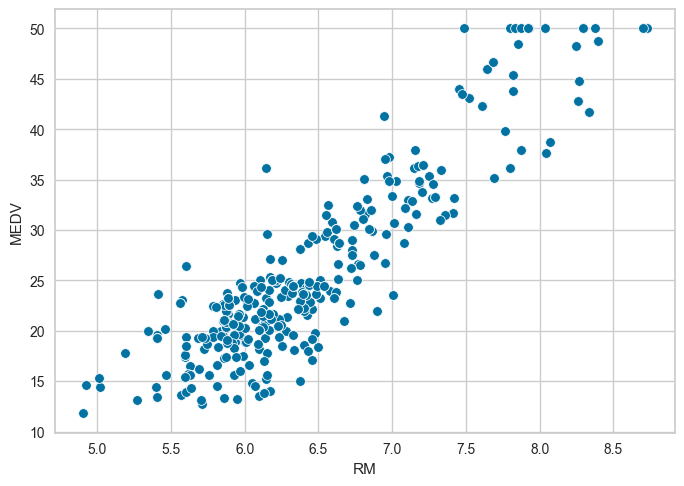

In [116]:
sns.scatterplot(data=df, x="RM", y="MEDV")


In [117]:
#X =X.drop(['Price'], axis=1)
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.09065,20.0,6.96,1,0.464,5.920,61.5,3.9175,3,223.0,18.6,391.34,13.65,20.7
396,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223.0,18.6,388.65,13.00,21.1
397,0.16211,20.0,6.96,0,0.464,6.240,16.3,4.4290,3,223.0,18.6,396.90,6.59,25.2
398,0.11460,20.0,6.96,0,0.464,6.538,58.7,3.9175,3,223.0,18.6,394.96,7.73,24.4


In [119]:
X = X.drop(['Price'], axis=1)
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [120]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [122]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((320, 13), (80, 13), (320,), (80,))

In [123]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
y_predict = model.predict(X_test)


In [125]:
y_predict, y_test

(array([19.91947023, 31.41898502, 24.62331888, 37.28735407, 20.14868485,
        15.32389244, 24.13784596, 39.22060694,  8.26719707, 18.78570178,
        20.75047205, 13.4321459 , 19.72308926, 31.41898502, 22.19262182,
        18.64463721, 24.89823545, 18.22910474, 24.89823545, 30.98042014,
        23.86508489, 41.23167057, 20.53663956, 22.41880608, 30.20490614,
        40.68542317, 22.05412013, 17.49555719, 40.65682541, 19.33257021,
        21.00907794, 24.0437124 , 22.88111278, 47.59386937, 27.19733734,
        22.13456339, 26.16596989, 26.23766918, 33.39069715, 39.66106479,
        24.84151446, 47.22721675, 21.68869951, 24.35287361, 20.25410035,
        14.48507643, 22.20783669, 20.35598986, 24.01942714, 42.98233139,
        18.22316185, 11.82908074, 18.31093897, 22.51126379, 41.8172527 ,
        35.27750027, 28.53309456, 22.33719086, 14.67181773, 20.60081301,
        26.4584227 , 27.85608066, 31.14995225, 41.35697943, 29.81418162,
        12.8674179 , 21.05431718, 24.19140731, 22.6

## How to Evaluate the Regression Model Performance

The `coefficient of determination`, $R^2$, to quantify the model's performance. `The coefficient of determination` for a model is a useful statistic in `regression analysis`, as it often describes how "good" that model is at estimating/ calculating predictions.

The values for $R^2$ range from `0` to `1`, which captures the percentage of `squared correlation` between the predicted and actual values of the target variable:
- R² = 1.0 → perfect prediction of the target variable
- R² = 0.8 → model explains 80% of the variance
- R² = 0.0 → model is no better than predicting the mean
- R² < 0 → model is worse than a horizontal line, i.e. no better than one that naively predicts the `mean` of the target variable:

For the `performance_metric function` in the code cell below, you will need to implement the following:

We use r2_score from `sklearn.metrics` to perform a performance calculation between `y_true` and `y_predict`

In [126]:
from sklearn.metrics import r2_score

r2= r2_score(y_test, y_predict) # coefficient of determination
print(f"R² score: {r2:.4f}")

R² score: 0.8585


In [127]:
mean_absolute_error(y_test, y_predict)

2.75898251869983

In [128]:
mean_squared_error(y_test, y_predict)

11.302907577327309

In [129]:
np.sqrt(mean_squared_error(y_test, y_predict))

np.float64(3.3619797110225558)

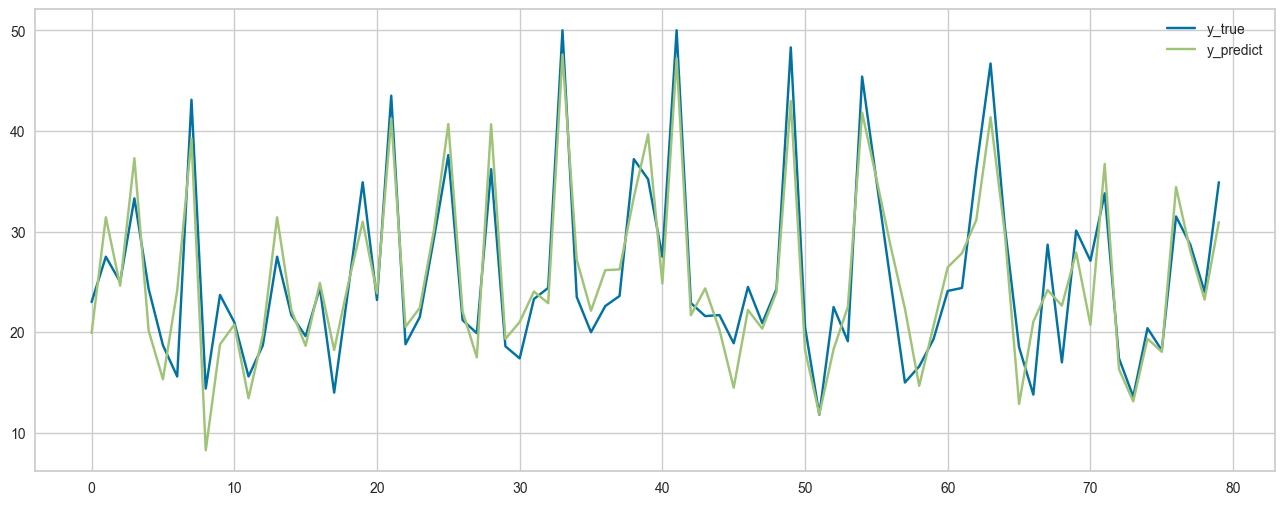

In [130]:
plt.subplots(figsize=(16,6))
x_points = list(range(len(y_test)))
plt.plot(x_points, y_test, label='y_true')
plt.plot(x_points, y_predict, label='y_predict')
plt.legend()
plt.show()

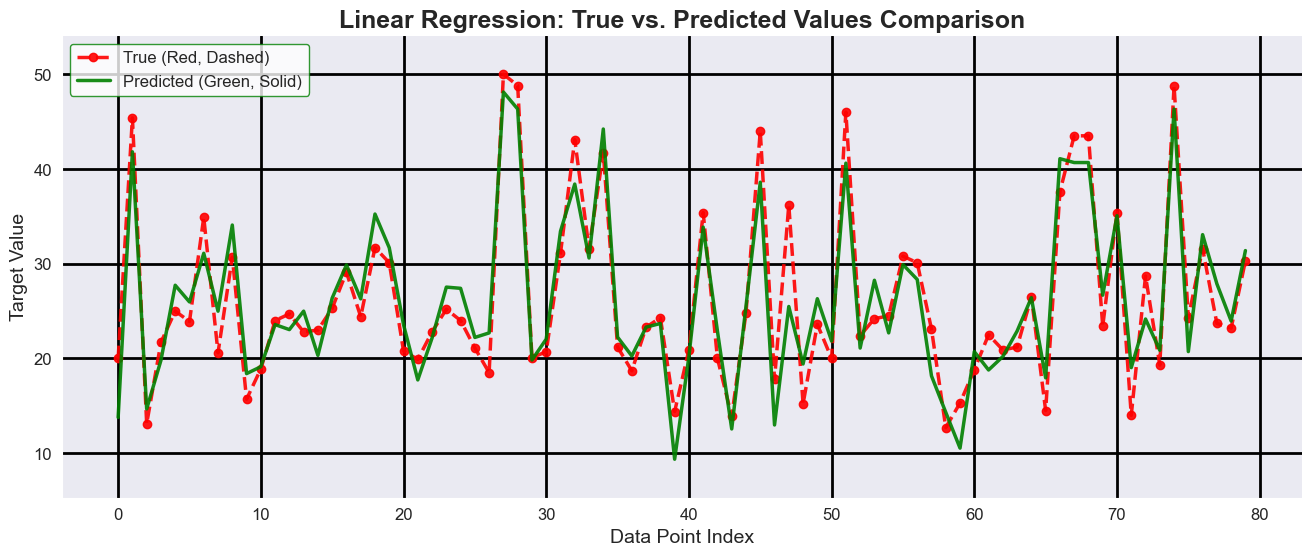

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_true_vs_predict_save(y_test, y_predict, filename='true_vs_predict_comparison.png'):

    # 1. Set the background to white and create a clean figure and axis.
    plt.rcParams['figure.facecolor'] = 'white'
    fig, ax = plt.subplots(figsize=(16, 6))

    # X-axis points (using the length of the data)
    x_points = np.arange(len(y_test))

    # 2. Add grid lines for better readability, using light grey.
    ax.grid(color='#000000', linestyle='-', linewidth=2)

    # 3. Plot the 'y_true' line: Firebrick red, clear dashed style, and small circle markers.
    ax.plot(x_points, y_test, color='red', linestyle='--', linewidth=2.5,
            marker='o', markersize=6, alpha=0.9, label='True (Red, Dashed)')

    # 4. Plot the 'y_predict' line: Vibrant emerald green, solid style, no markers.
    ax.plot(x_points, y_predict, color='green', linestyle='-', linewidth=2.5,
            alpha=0.9, label='Predicted (Green, Solid)')

    # 5. Add titles and labels with appropriate font sizes.
    ax.set_title('Linear Regression: True vs. Predicted Values Comparison', fontsize=18, fontweight='bold')
    ax.set_ylabel('Target Value', fontsize=14)
    ax.set_xlabel('Data Point Index', fontsize=14)

    # 6. Customize tick labels and general clean look.
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 7. Add a clean legend in the best position.
    ax.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='green')

    # 8. Set limits to give some space around the plot.
    y_min, y_max = min(np.min(y_test), np.min(y_predict)), max(np.max(y_test), np.max(y_predict))
    padding = (y_max - y_min) * 0.1
    ax.set_ylim(y_min - padding, y_max + padding)

    # Tighten layout before saving/displaying
  #  plt.tight_layout()

    # 9. Save the figure
    fig.savefig(filename, dpi=300, bbox_inches='tight')  #  bbox_inches='tight' for clean padding

    # 10. Also display the plot to the screen as you wanted previously.
    plt.show()

# --- Execution ---
plot_true_vs_predict_save(y_test, y_predict, 'my_regression_plot.png')

In [131]:
from sklearn.model_selection import learning_curve, ShuffleSplit


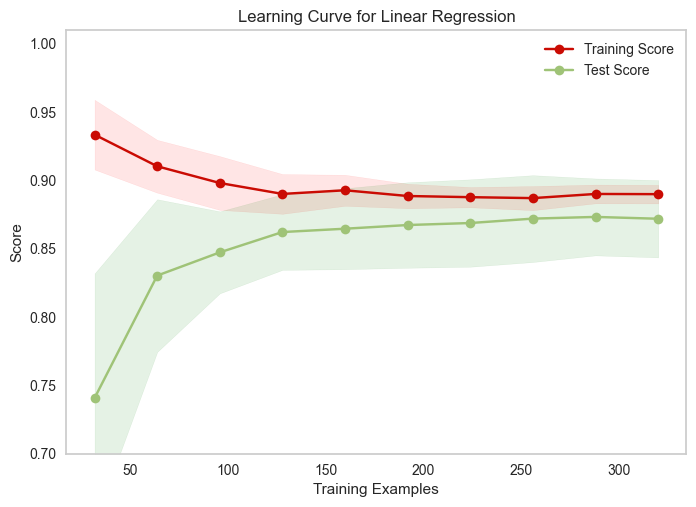

In [134]:

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        train_size=np.linspace(0.1, 1, 10)):
    # 1. Clear previous figures from memory
    plt.clf()

    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel('Training Examples')
    plt.ylabel('Score')

    # 2. Added n_jobs=-1 to utilize multiple cores if available
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_size, n_jobs=-1)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='red')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='green')

    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test Score')

    plt.legend(loc='best')
    plt.show() # 3. display and flush the plot builder
    plt.close() # 4. free up the memory used by this plot

# --- Execution ---
title = 'Learning Curve for Linear Regression'

# CRITICAL FIX: Lower n_splits from 100 to 5 or 10
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

model = LinearRegression()
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv)

## Residual Plots

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

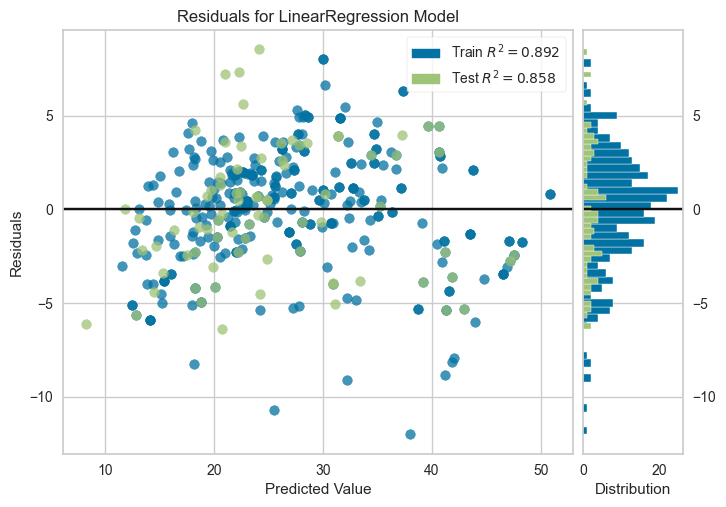

In [161]:
import warnings
import matplotlib.pyplot as plt
from yellowbrick.regressor import ResidualsPlot

warnings.filterwarnings("ignore", message="X does not have valid feature names")

viz = ResidualsPlot(model)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)

# This saves AND shows the plot in one clean step without losing the canvas
viz.show(outpath="residual_plots.png", dpi=300, bbox_inches='tight')


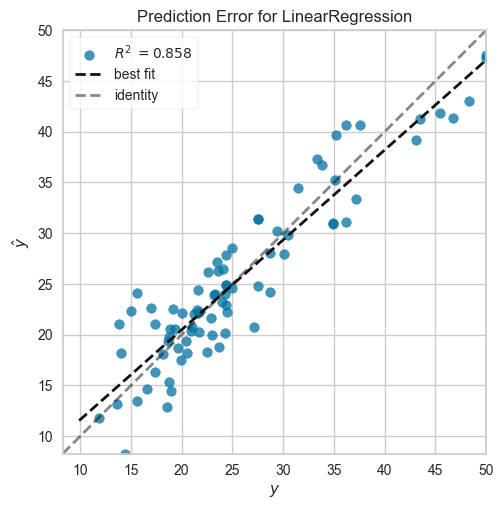

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [154]:
from yellowbrick.regressor import PredictionError
warnings.filterwarnings("ignore", message="X does not have valid feature names")

model._estimator_type = "regressor"

viz = PredictionError(model)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()